In [10]:
import numpy as np
import pandas as pd

In [11]:
df = pd.read_csv('C:/Users/bhard/OneDrive/Desktop/Sms Spam Detector/spam.csv', encoding = 'latin-1')

In [12]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [14]:
#1.Data cleaning
#2.EDA
#3.Test Preprocessing
#4.Model Building
#5.Evaluation
#6.Improvement
#7.Website 
#8.Deploy

# Data Cleaning

In [15]:
df.drop(columns = ["Unnamed: 2","Unnamed: 3","Unnamed: 4"], inplace=True)

In [16]:
df.describe()

,v1,v2
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [17]:
df.rename(columns = {'v1':'Target','v2':'Text'},inplace = True)

In [18]:
df

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [19]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [20]:
df['Target'] = encoder.fit_transform(df['Target'])

In [21]:
df

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [22]:
#missing value
df.isnull().sum()

Target    0
Text      0
dtype: int64

In [23]:
#duplicates value
df.duplicated().sum()

np.int64(403)

In [24]:
#removing duplicates
df = df.drop_duplicates(keep="first")

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


# EDA

In [27]:
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

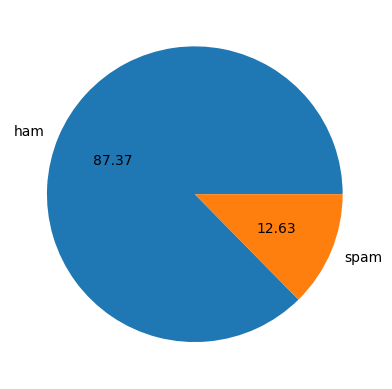

In [28]:
import matplotlib.pyplot as plt
plt.pie(df['Target'].value_counts(),labels=['ham','spam'], autopct = '%0.2f')
plt.show()

In [29]:
# data is imbalances
import nltk

In [30]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [31]:
df['Num_Characters'] = df['Text'].apply(len)

In [32]:
df['Num_Words'] = df['Text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [33]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bhard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [34]:
df

,Target,Text,Num_Characters,Num_Words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35
5568,0,Will Ì_ b going to esplanade fr home?,37,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [35]:
df['Num_Sentences'] = df['Text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [36]:
df[['Num_Sentences','Num_Characters','Num_Words']].describe()

,Num_Sentences,Num_Characters,Num_Words
count,5169.000000,5169.000000,5169.000000
mean,1.965564,78.977945,18.455794
std,1.448541,58.236293,13.324758
min,1.000000,2.000000,1.000000
25%,1.000000,36.000000,9.000000
50%,1.000000,60.000000,15.000000
75%,2.000000,117.000000,26.000000
max,38.000000,910.000000,220.000000


In [37]:
#ham
df[df['Target']==0][['Num_Sentences','Num_Characters','Num_Words']].describe()

,Num_Sentences,Num_Characters,Num_Words
count,4516.000000,4516.000000,4516.000000
mean,1.820195,70.459256,17.123782
std,1.383657,56.358207,13.493970
min,1.000000,2.000000,1.000000
25%,1.000000,34.000000,8.000000
50%,1.000000,52.000000,13.000000
75%,2.000000,90.000000,22.000000
max,38.000000,910.000000,220.000000


In [38]:
#spam
df[df['Target']==1][['Num_Sentences','Num_Characters','Num_Words']].describe()

,Num_Sentences,Num_Characters,Num_Words
count,653.000000,653.000000,653.000000
mean,2.970904,137.891271,27.667688
std,1.488425,30.137753,7.008418
min,1.000000,13.000000,2.000000
25%,2.000000,132.000000,25.000000
50%,3.000000,149.000000,29.000000
75%,4.000000,157.000000,32.000000
max,9.000000,224.000000,46.000000


In [39]:
import seaborn as sns

<Axes: xlabel='Num_Characters', ylabel='Count'>

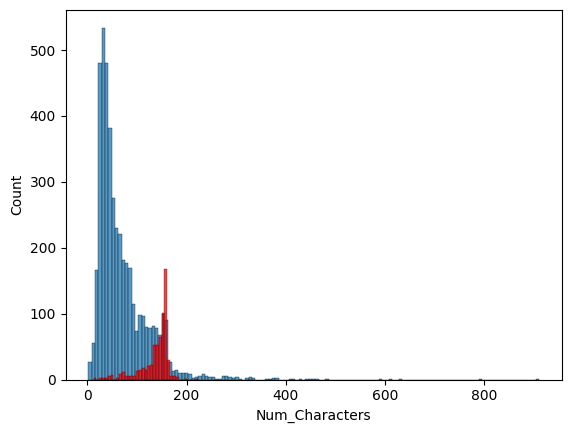

In [40]:
sns.histplot(df[df['Target']==0]['Num_Characters'])
sns.histplot(df[df['Target']==1]['Num_Characters'],color = 'red')

<Axes: xlabel='Num_Words', ylabel='Count'>

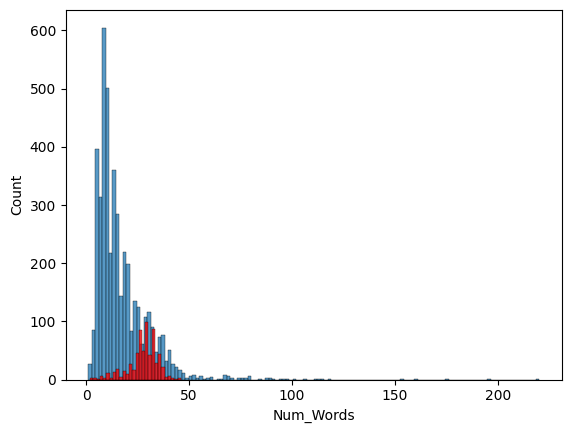

In [41]:
sns.histplot(df[df['Target']==0]['Num_Words'])
sns.histplot(df[df['Target']==1]['Num_Words'],color = 'red')

<Axes: xlabel='Num_Sentences', ylabel='Count'>

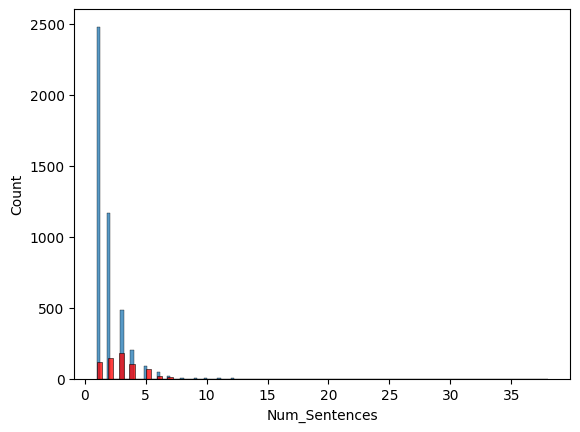

In [42]:
sns.histplot(df[df['Target']==0]['Num_Sentences'])
sns.histplot(df[df['Target']==1]['Num_Sentences'],color = 'red')

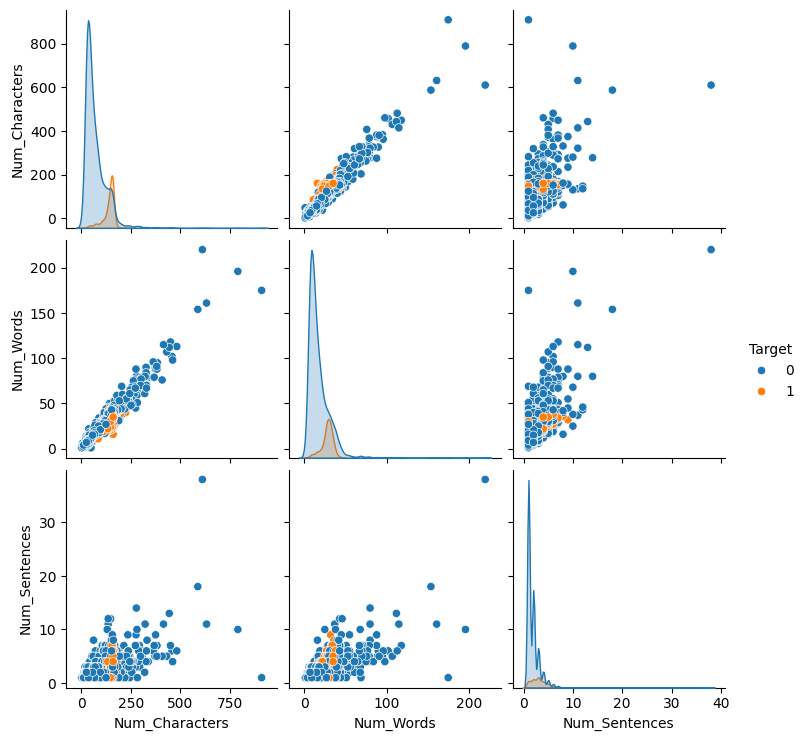

In [43]:
sns.pairplot(df, hue = 'Target')

<Axes: >

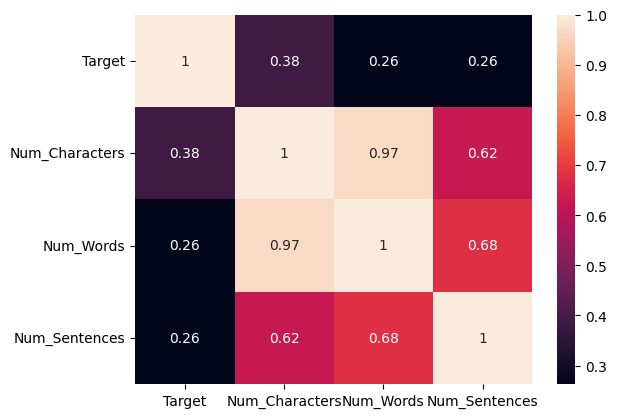

In [44]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

# Data Preprocessing

In [45]:
#Lower case
#Tokenization
#Removing Special Characters
#Removing Stop Words and Punctuation
#Stemming


In [70]:
def transform_text(Text):
    Text = Text.lower()
    Text = nltk.word_tokenize(Text)

    y = []
    for i in Text:
        if i.isalnum():
            y.append(i)

    Text = y[:]
    y.clear()

    for i in Text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    Text = y[:]
    y.clear()

    for i in Text:
        y.append(ps.stem(i))

    return " ".join(y)

In [71]:
transform_text('Did you like my presentation on ML ?')

'like present ml'

In [72]:
df['Text'][2000]

"But i'll b going 2 sch on mon. My sis need 2 take smth."

In [73]:
from nltk.stem.porter import PorterStemmer

In [74]:
from nltk.corpus import stopwords

In [75]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [76]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [77]:
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [79]:
df['Transformed_Text'] = df['Text'].apply(transform_text)

In [80]:
df.head()

,Target,Text,Num_Characters,Num_Words,Num_Sentences,Transformed_Text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [87]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height = 500, min_font_size = 10, background_color = 'white')

In [83]:
!pip install wordcloud

In [88]:
spam_wc = wc.generate(df[df['Target']==1]['Transformed_Text'].str.cat(sep=" "))

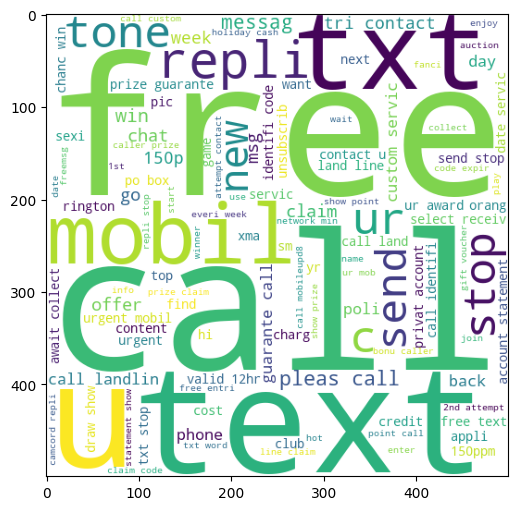

In [92]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

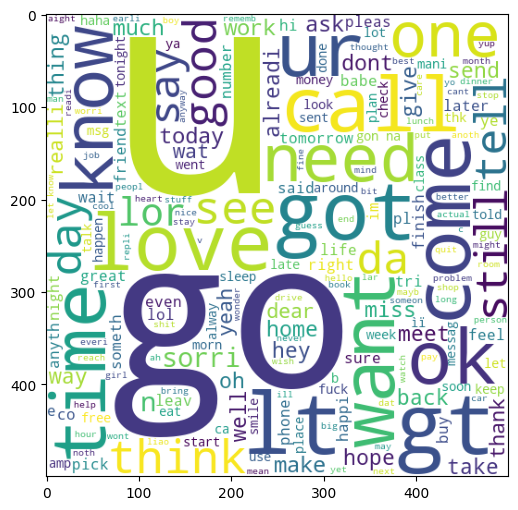

In [93]:
ham_wc = wc.generate(df[df['Target']==0]['Transformed_Text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [94]:
spam_corpus = []
for msg in df[df['Target']==1]['Transformed_Text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [95]:
len(spam_corpus)

9939

In [96]:
from collections import Counter

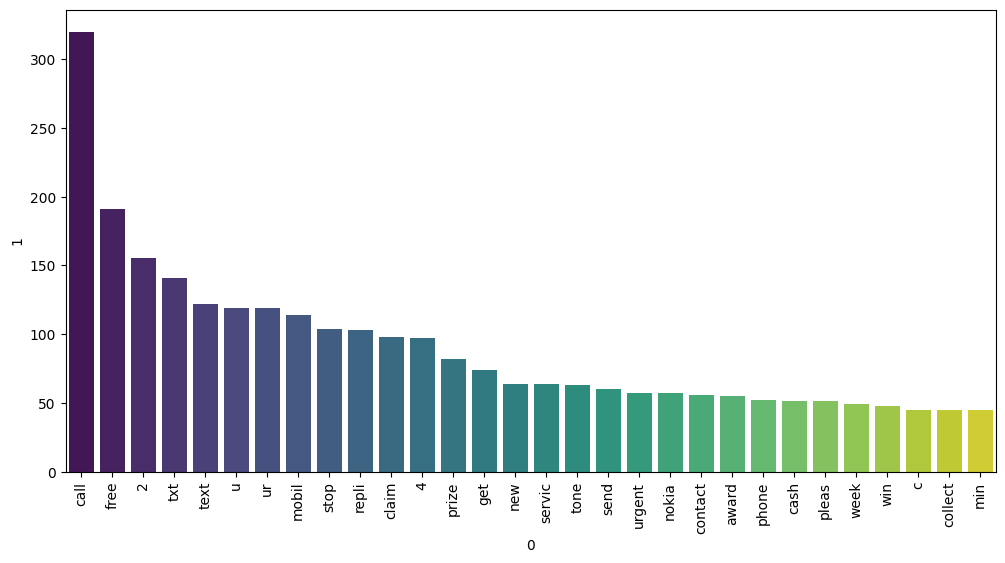

In [104]:
# Create a DataFrame from the 30 most common words
top_30_spam = pd.DataFrame(Counter(spam_corpus).most_common(30))

plt.figure(figsize=(12, 6)) # Added to give the plot more breathing room

# Using the 'viridis' palette for colorful bars
sns.barplot(
    x=top_30_spam[0], 
    y=top_30_spam[1], 
    palette='viridis', 
    hue=top_30_spam[0], 
    legend=False
)

plt.xticks(rotation='vertical')
plt.show()

In [107]:
ham_corpus = []
for msg in df[df['Target']==0]['Transformed_Text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [108]:
len(ham_corpus)

35404

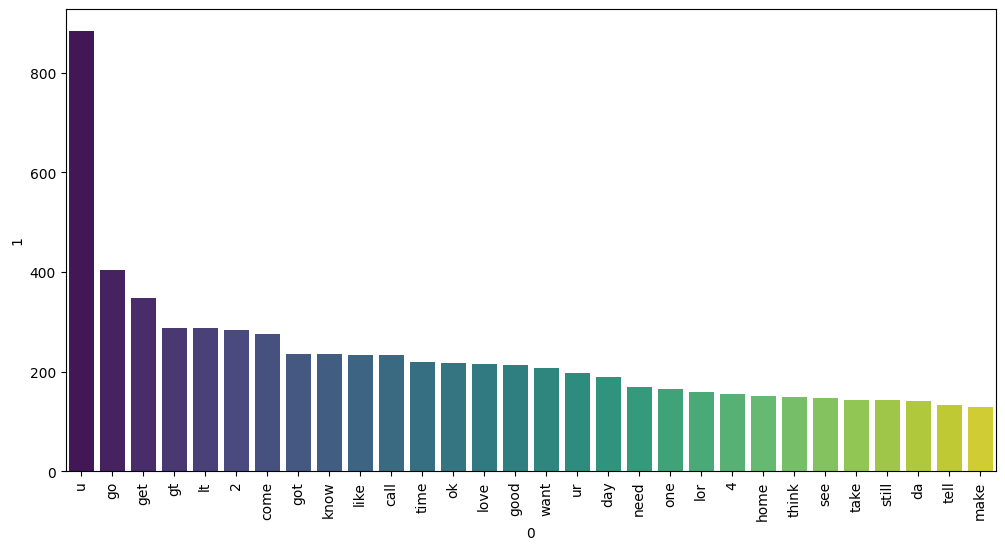

In [109]:
# Create a DataFrame from the 30 most common words
top_30_ham = pd.DataFrame(Counter(ham_corpus).most_common(30))

plt.figure(figsize=(12, 6)) # Added to give the plot more breathing room

# Using the 'viridis' palette for colorful bars
sns.barplot(
    x=top_30_ham[0], 
    y=top_30_ham[1], 
    palette='viridis', 
    hue=top_30_ham[0], 
    legend=False
)

plt.xticks(rotation='vertical')
plt.show()

# Model Building

In [187]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features = 3000)

In [188]:
x = tfidf.fit_transform(df['Transformed_Text']).toarray()

In [189]:
x.shape

(5169, 3000)

In [190]:
y = df['Target'].values

In [191]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [192]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [193]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state = 2)

In [194]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [195]:
gnb.fit(x_train, y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [196]:
mnb.fit(x_train, y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [197]:
bnb.fit(x_train, y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [198]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [199]:
svc = SVC(kernel = 'sigmoid', gamma = 1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver = 'liblinear', l1_ratio = 1)
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2)
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
gbdt = GradientBoostingClassifier(n_estimators = 50, random_state = 2)
xgb = XGBClassifier(n_estimators = 50, random_state = 2)

In [200]:
clfs = {
    'SVC':svc,
    'KN':knc,
    'NB':mnb,
    'DT':dtc,
    'LR':lrc,
    'RF':rfc,
    'AdaBoost':abc,
    'BgC':bc,
    'ETC':etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [201]:
def train_classifier(clf, x_train, y_train, x_test, y_test):
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [202]:
train_classifier(svc, x_train, y_train, x_test, y_test)

(0.9758220502901354, 0.9747899159663865)

In [203]:
accuracy_scores = []
precision_scores = []
for name,clf in clfs.items():

    current_accuracy, current_precision = train_classifier(clf, x_train, y_train, x_test, y_test)

    print('For ',name)
    print('Accuracy ',current_accuracy)
    print('Precision ',current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy  0.9758220502901354
Precision  0.9747899159663865
For  KN
Accuracy  0.9052224371373307
Precision  1.0
For  NB
Accuracy  0.9709864603481625
Precision  1.0
For  DT
Accuracy  0.9313346228239845
Precision  0.8383838383838383
For  LR
Accuracy  0.9555125725338491
Precision  0.96
For  RF
Accuracy  0.9738878143133463
Precision  0.9826086956521739
For  AdaBoost
Accuracy  0.9216634429400387
Precision  0.8202247191011236
For  BgC
Accuracy  0.9584139264990329
Precision  0.8682170542635659
For  ETC
Accuracy  0.9748549323017408
Precision  0.9745762711864406
For  GBDT
Accuracy  0.9506769825918762
Precision  0.9306930693069307
For  xgb
Accuracy  0.9680851063829787
Precision  0.9487179487179487


In [204]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(), 'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Accuracy',ascending=False)

In [205]:
performance_df

,Algorithm,Accuracy,Precision
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
5,RF,0.973888,0.982609
2,NB,0.970986,1.000000
10,xgb,0.968085,0.948718
7,BgC,0.958414,0.868217
4,LR,0.955513,0.960000
9,GBDT,0.950677,0.930693
3,DT,0.931335,0.838384
6,AdaBoost,0.921663,0.820225


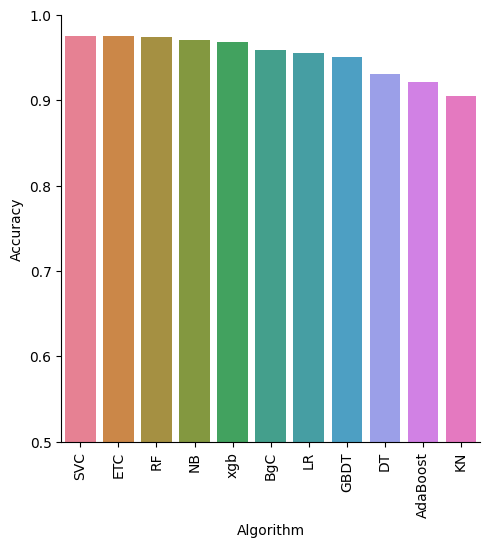

In [206]:
sns.catplot(x = 'Algorithm', y = 'Accuracy', hue = 'Algorithm', data = performance_df, kind = 'bar', height = 5)
plt.ylim(0.5, 1.0)
plt.xticks(rotation = 'vertical')
plt.show()

In [207]:
from sklearn.preprocessing import MinMaxScaler
scaler =MinMaxScaler()
x = scaler.fit_transform(x)

In [208]:
import pickle
pickle.dump(tfidf,open('vecctorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))